# Business Problem:

In recent years, City Hotel and Resort Hotel have seen high cancellation rates. Each hotel is now dealing with a number of issues as a result, including revenues and less than ideal hotel room use. Consequently, lowering cacellation rates is both hotes primary goal in order to increase their efficiency in generating revenue and for use too offer through business advice to address this probelem.

The analysis of hotel booking cancellations as well as other factors that have no bearning on their business and yearly revenue generating are the main topics of this report.

## Assumptions:
>1. No unusal occurrences between 2015 and 2017 will have a substancial impact on the data used.
>2. The information is still current and can be used to analyze a hotel's possible plans in an efficient manner.
>3. There are no unanticioated negatives to the hotel employing any advised technique.
>4. The hotels are not currently using any of the suggested solutions.
>5. The biggest factor affecting the effectiveness of earning income is bookiing cacellations.
>6. Cancellations result in va ant rooms for the booked length of time.
>7. Clients make hotel reservation the same year they make cancellations.

## Research Questions:
>1. What are the variables that affect hotel reservations cancellations?
>2. How can we make hotel reservations cancellations better?
>3. How will hotels be assisted in making pricing and promotional decisions?

### Hypothesis:
>1. More cancellations occur when prices are higher.
>2. When there is a longer waiting list, customers tend to cancel more frequently.
>3. The majority of clients are comings from offline travel agents to make their reservations.
>   

## Importing libraries:

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
#!pip install seaborn

## loading the dataset:

In [6]:
df = pd.read_csv('hotel_booking.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


## Exploratory data analysis:

In [7]:
df.shape

(119390, 36)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'name', 'email',
       'phone-number', 'credit_card'],
      dtype='object')

In [10]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,name,email,phone-number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,669-792-1661,************3627
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,48,6,1,28


In [11]:
# change data type:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [13]:
for col in df.describe(include='object'):
    print(col)
    print(df[col].unique())
    print('-'* 50)

hotel
['Resort Hotel' 'City Hotel']
--------------------------------------------------
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
--------------------------------------------------
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
--------------------------------------------------
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'J

In [14]:
# missing data:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [15]:
df.drop(columns = ['company', 'agent'], inplace= True)
df.dropna(inplace = True)

In [16]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [18]:
# summary statistics for numerical columns.
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809984
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


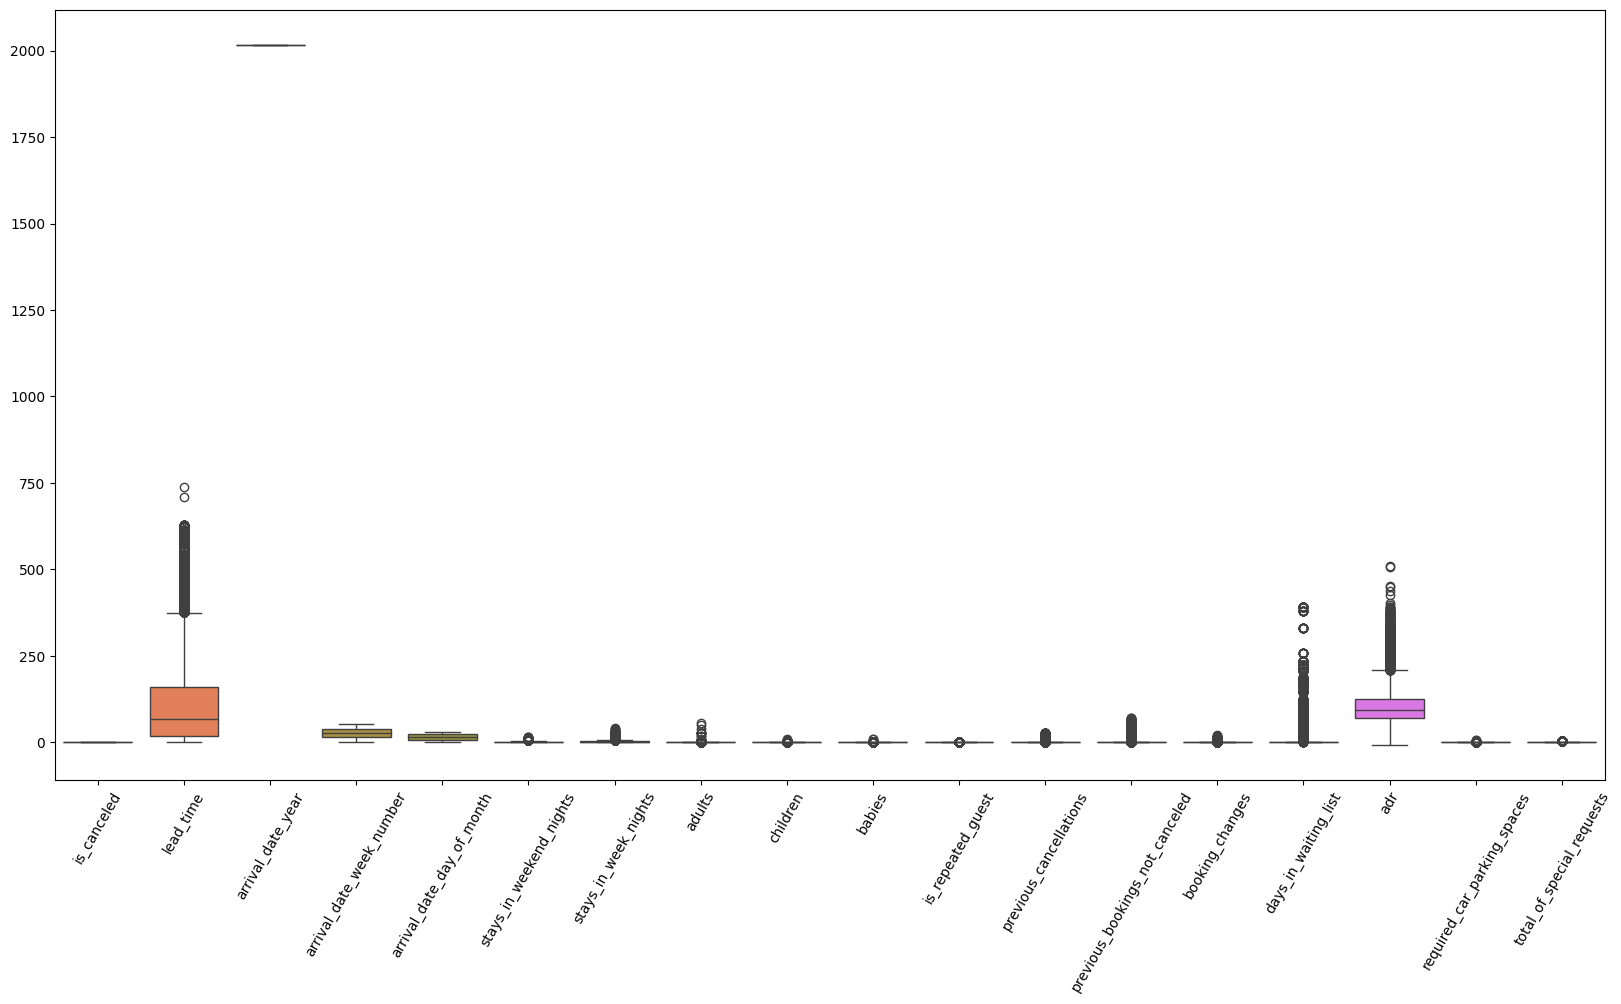

In [26]:
plt.figure(figsize=(20,10))
sns.boxplot(df)
plt.xticks(rotation = 60)
plt.show()

In [19]:
df = df[df['adr']<5000]

### Data Analysis and visualizations:

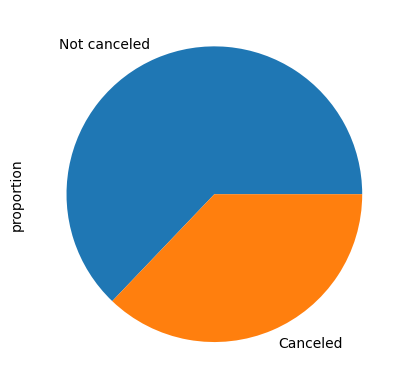

In [34]:
canceled_pct = df['is_canceled'].value_counts(normalize=True)
canceled_pct.plot(kind = 'pie', labels = ['Not canceled', 'Canceled'])
plt.show()

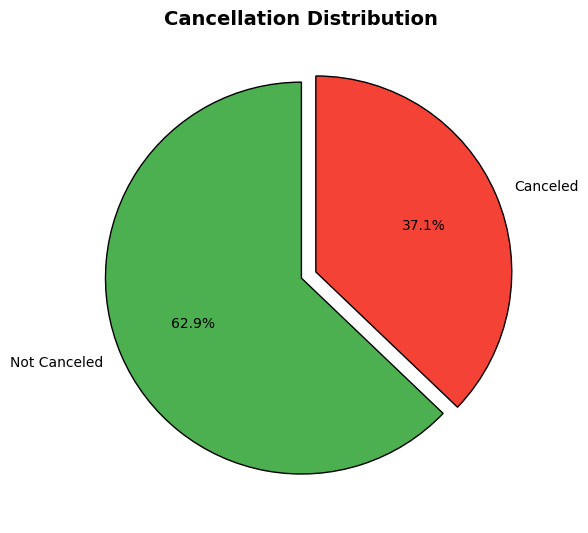

In [38]:
plt.figure(figsize=(6,6))

canceled_pct = df['is_canceled'].value_counts(normalize=True)

colors = ['#4CAF50', '#F44336']  # green = not canceled, red = canceled

canceled_pct.plot(
    kind='pie',
    labels=['Not Canceled', 'Canceled'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0, 0.08],  # highlight canceled
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Cancellation Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

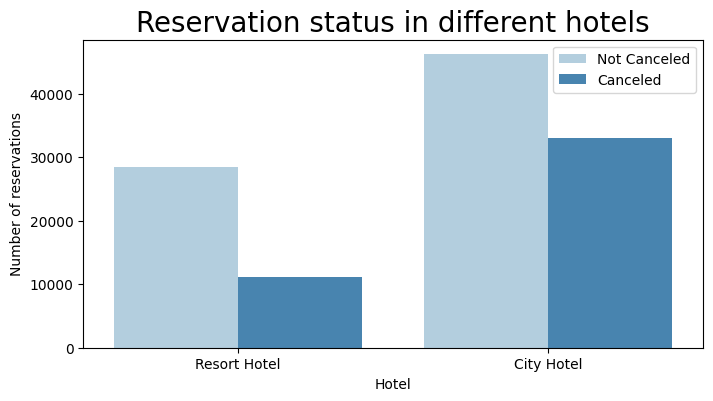

In [37]:
plt.figure(figsize=(8,4))
ax1 = sns.countplot(x = 'hotel', hue = 'is_canceled', data = df, palette='Blues')
legend_labels,_ = ax1.get_legend_handles_labels()
ax1.legend(bbox_to_anchor= (1,1))
plt.title('Reservation status in different hotels', size = 20)
plt.xlabel('Hotel')
plt.ylabel('Number of reservations')
plt.legend(['Not Canceled', 'Canceled'])
plt.show()

In [39]:
resort_hotel = df[df['hotel'] == 'Resort Hotel']
resort_hotel.is_canceled.value_counts(normalize = True)

is_canceled
0    0.72025
1    0.27975
Name: proportion, dtype: float64

In [40]:
city_hotel = df[df['hotel'] == 'City Hotel']
city_hotel.is_canceled.value_counts(normalize = True)

is_canceled
0    0.582918
1    0.417082
Name: proportion, dtype: float64

In [41]:
resort_hotel = resort_hotel.groupby('reservation_status_date')[['adr']].mean()
city_hotel = city_hotel.groupby('reservation_status_date')[['adr']].mean()

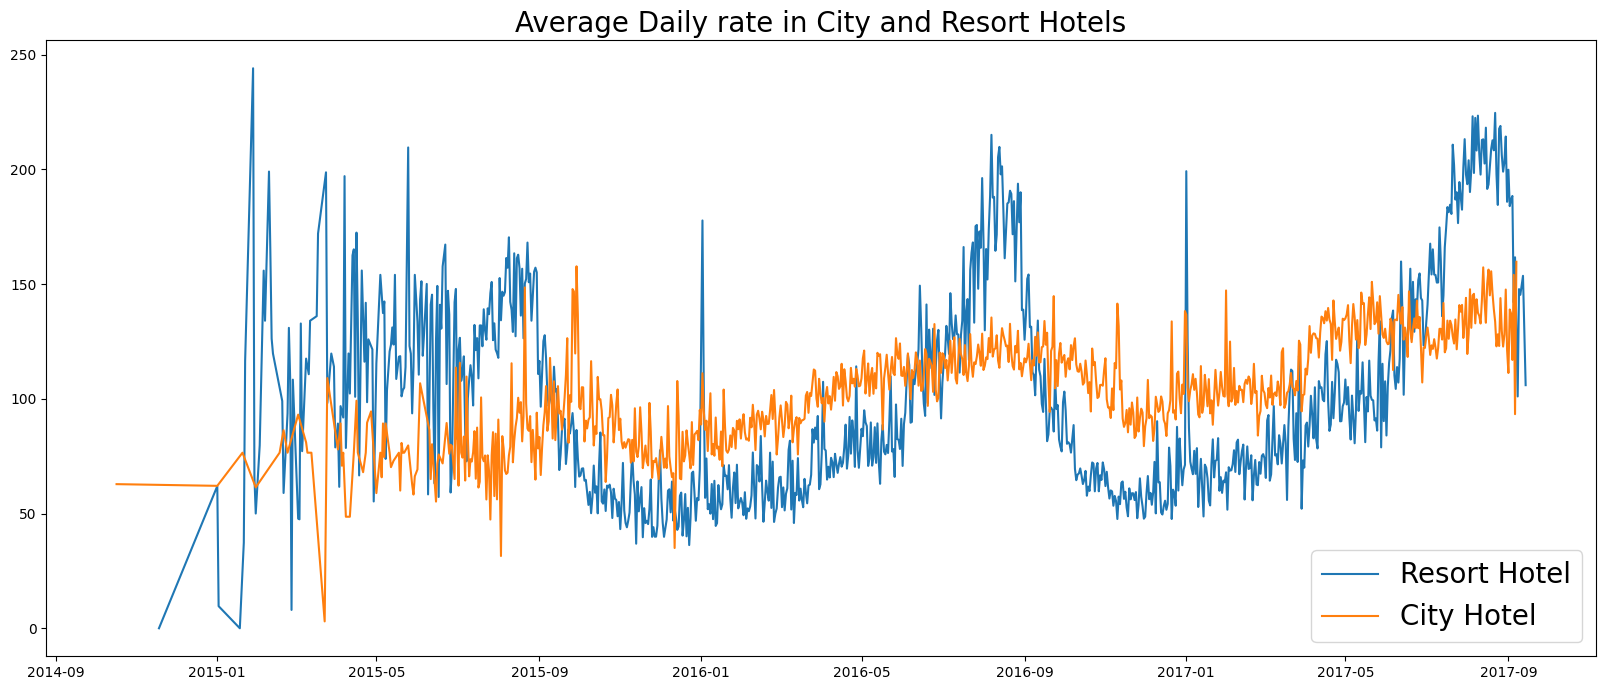

In [42]:
plt.figure(figsize=(20,8))
plt.title('Average Daily rate in City and Resort Hotels', fontsize = 20)
plt.plot(resort_hotel.index, resort_hotel['adr'], label = 'Resort Hotel')
plt.plot(city_hotel.index, city_hotel['adr'], label = 'City Hotel')
plt.legend(fontsize = 20)
plt.show()

In [43]:
df['month'] = df['reservation_status_date'].dt.month

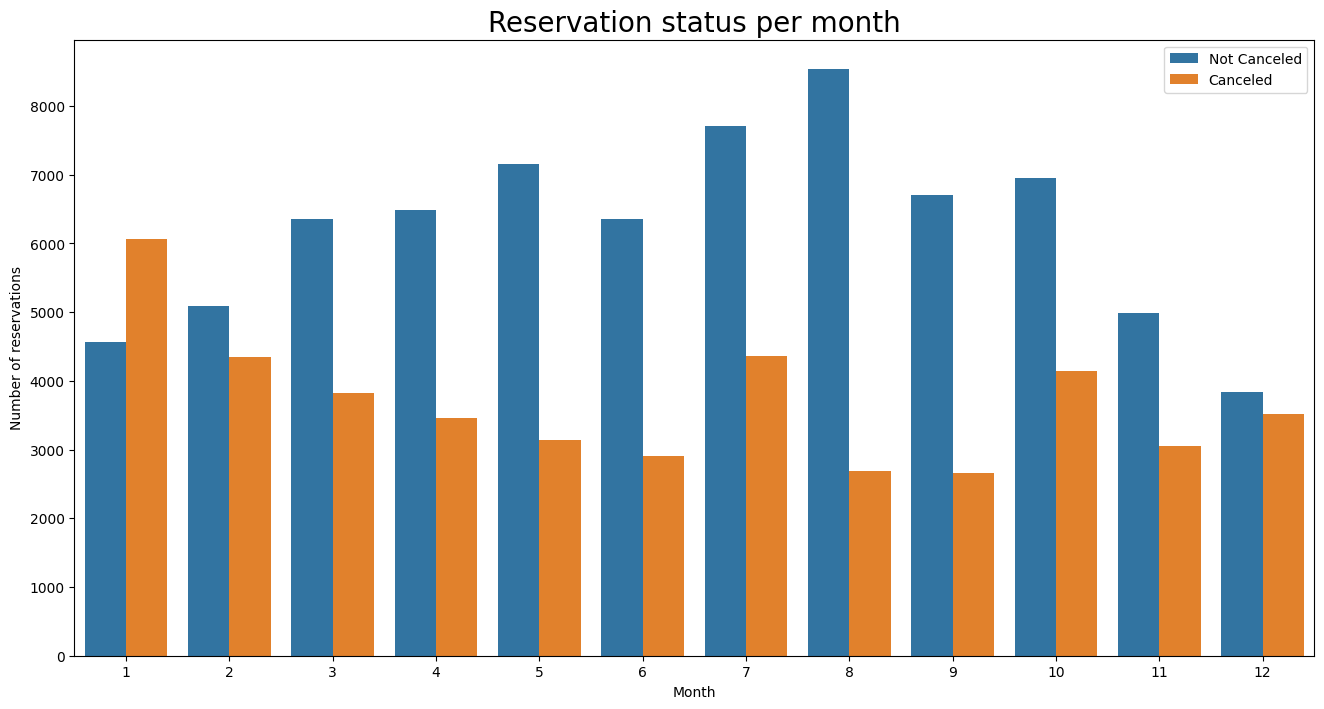

In [44]:
plt.figure(figsize=(16,8))
ax1 = sns.countplot(x = 'month', hue = 'is_canceled', data = df)
ax1.legend(bbox_to_anchor = (1,1))
plt.title('Reservation status per month', size = 20)
plt.xlabel('Month')
plt.ylabel('Number of reservations')
plt.legend(['Not Canceled', 'Canceled'])
plt.show()

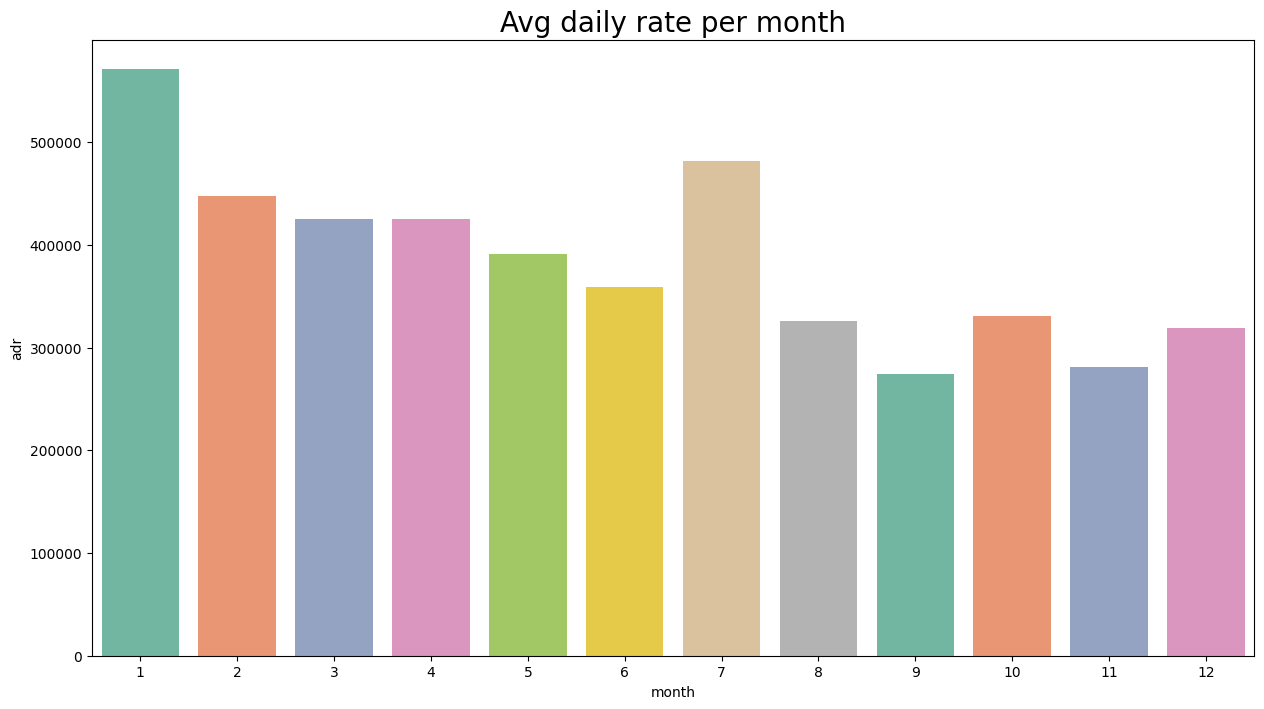

In [49]:
adr = df[df['is_canceled'] == 1].groupby('month')[['adr']].sum().reset_index()
plt.figure(figsize=(15,8))
plt.title('Avg daily rate per month', fontsize = 20)
sns.barplot(data = adr, x = 'month', y = 'adr', palette='Set2')
plt.show()

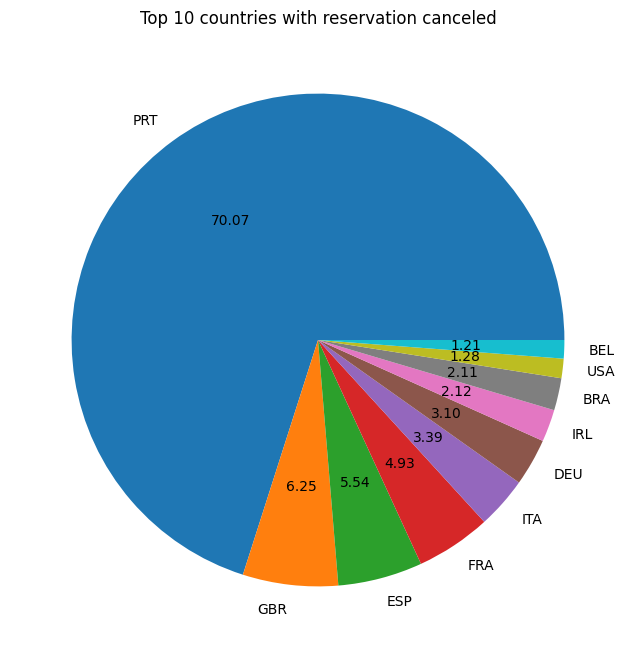

In [51]:
canceled_data = df[df['is_canceled'] ==1]
top10_country = canceled_data['country'].value_counts()[:10]
plt.figure(figsize = (8,8))
plt.title('Top 10 countries with reservation canceled')
plt.pie(top10_country, autopct='%.2f', labels=top10_country.index)
plt.show()

In [52]:
df['market_segment'].value_counts(normalize = True)

market_segment
Online TA        0.474377
Offline TA/TO    0.203193
Groups           0.166581
Direct           0.104696
Corporate        0.042987
Complementary    0.006173
Aviation         0.001993
Name: proportion, dtype: float64

In [53]:
canceled_data['market_segment'].value_counts(normalize = True)

market_segment
Online TA        0.469696
Groups           0.273985
Offline TA/TO    0.187466
Direct           0.043486
Corporate        0.022151
Complementary    0.002038
Aviation         0.001178
Name: proportion, dtype: float64

In [54]:
not_canceled_df = df[df['is_canceled']==0]

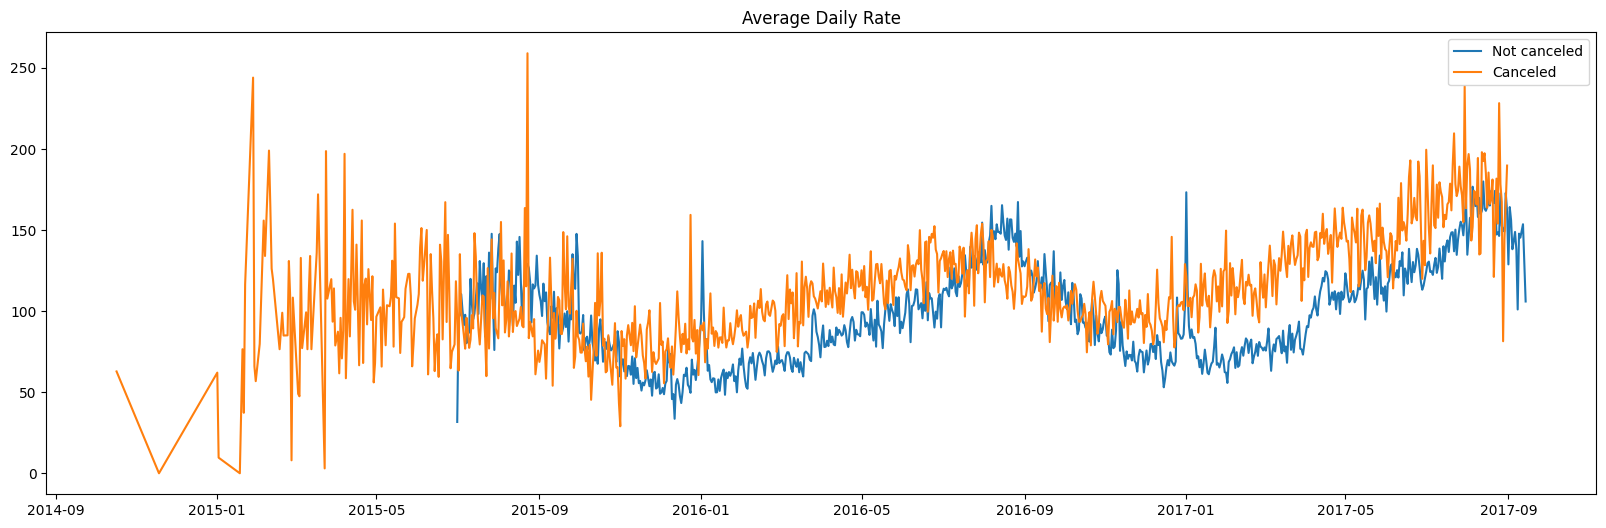

In [56]:
canceled_df_adr = canceled_data.groupby('reservation_status_date')[['adr']].mean()
canceled_df_adr.reset_index(inplace =True)
canceled_df_adr.sort_values('reservation_status_date', inplace = True)

not_canceled_df_adr = not_canceled_df.groupby('reservation_status_date')[['adr']].mean()
not_canceled_df_adr.reset_index(inplace =True)
not_canceled_df_adr.sort_values('reservation_status_date', inplace = True)

plt.figure(figsize=(20,6))
plt.title('Average Daily Rate')
plt.plot(not_canceled_df_adr['reservation_status_date'], not_canceled_df_adr['adr'], label = 'Not canceled')
plt.plot(canceled_df_adr['reservation_status_date'], canceled_df_adr['adr'], label = 'Canceled')
plt.legend()
plt.show()

In [57]:
canceled_df_adr = canceled_df_adr[(canceled_df_adr['reservation_status_date']>'2016') & (canceled_df_adr['reservation_status_date']<'2017-09')]
not_canceled_df_adr = not_canceled_df_adr[(not_canceled_df_adr['reservation_status_date']>'2016') & (not_canceled_df_adr['reservation_status_date']<'2017-09')]

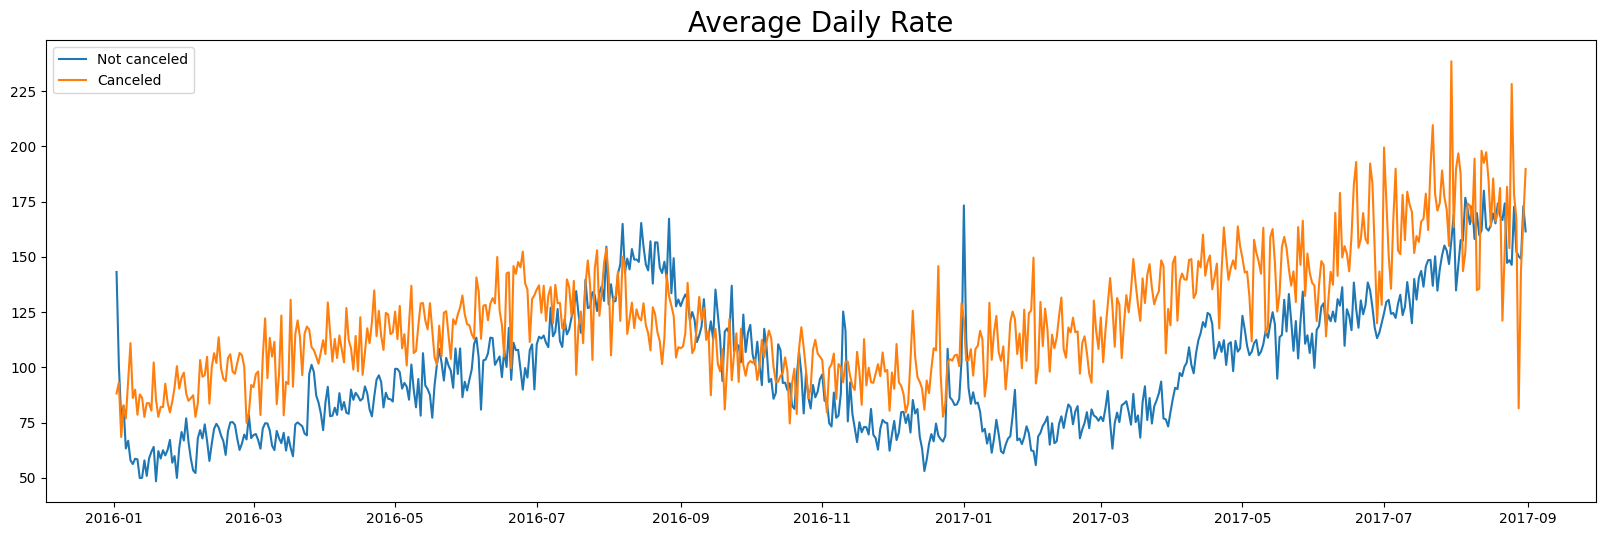

In [59]:
plt.figure(figsize=(20,6))
plt.title('Average Daily Rate', fontsize = 20)
plt.plot(not_canceled_df_adr['reservation_status_date'], not_canceled_df_adr['adr'], label = 'Not canceled')
plt.plot(canceled_df_adr['reservation_status_date'], canceled_df_adr['adr'], label = 'Canceled')
plt.legend()
plt.show()

# Recommendations:

>1. Cancellation rate rise as the price increases. In order to prevent cancellations of the reservations, hotes could workd on their pricing strategies and try to lower the rates for sepcific hotels basesd on locations. They can also provide some discounts to the customers.
>2. as the ratio of the cancellations and not cancellations of the resort hotel is higher in the resort hotel thant the city hotels. SO, the hotest should provide a reasonable discount on the room prices on weekends or on holidays.
>3. In the month of the Januarym Hotels can start campaigns or marketing with a reasonable amount to increase their revenye as the cancellation is the higest in this month.
>4. they can also increase thte quality of their hotels and their services mainly in Protugar to reduce the cancelation rates.